# Odkrywanie segmentów zużycia danych abonentów za pomocą PROC FASTCLUS

## Podsumowanie wykonawcze

Zespół analityki telekomunikacyjnej chce podzielić bazę abonentów mobilnych według **miesięcznego zużycia danych** bez narzucania dowolnych progów GB. Używając **PROC FASTCLUS** — wysokowydajnej procedury grupowania metodą *k*-średnich w SAS — pozwalamy, aby dane same podzieliły się na ukryte klasy użytkowania (lekkich, umiarkowanych i intensywnych użytkowników danych). FASTCLUS znajduje środek każdego segmentu, przypisuje każdego abonenta do najbliższego z nich i raportuje, jak wyraźnie segmenty się oddzielają — zamieniając pojedynczą ciągłą miarę użytkowania w praktyczną, opartą na danych segmentację do projektowania planów taryfowych i marketingu ukierunkowanego.

## Źródła danych

Wszystkie dane są generowane w pierwszym kroku DATA — nie ma plików zewnętrznych ani wywołań sieciowych. Abonenci pochodzą z populacji o trzech składowych użytkowania, dzięki czemu odzyskane segmenty można zweryfikować względem znanej prawdy odniesienia.

| Zbiór danych | Wiersze | Zmienna | Typ | Opis |
|---------|------|----------|------|-------------|
| `subscribers` | 1500 | `id` | Liczbowa | Identyfikator abonenta (1-1500) |
| `subscribers` | 1500 | `data_gb` | Liczbowa | Miesięczne zużycie danych mobilnych w GB (miara, na której grupujemy) |
| `subscribers` | 1500 | `segment_true` | Znakowa | Ukryty segment użyty do *wygenerowania* wartości (Lekki ≈ N(3,1²) 50%, Sredni ≈ N(12,3²) 35%, Ciezki ≈ N(35,8²) 15%); ukryty jedynie do walidacji odzyskanych segmentów — prawdziwy analityk by go nie obserwował |

# Odkrywanie segmentów zużycia danych abonentów

Operatorzy komórkowi rzadko mają czystą etykietę mówiącą *"to jest intensywny użytkownik danych"*. Mają za to ciągłą miarę — gigabajty zużyte miesięcznie — której rozkład jest **wielomodalny**: skupiska lekkich, umiarkowanych i mocnych użytkowników nakładają się na jednej osi. **Analiza skupień** traktuje tę pojedynczą kolumnę jako problem geometryczny: lokalizuje naturalne środki masy w rozkładzie użytkowania i przypisuje każdego abonenta do najbliższego z nich, bez ręcznie dobieranych progów.

W tym notatniku:

1. Generujemy realistyczną syntetyczną bazę abonentów, których zużycie danych pochodzi z trzech ukrytych segmentów.
2. Sprawdzamy rozkład brzegowy użytkowania, aby potwierdzić jego wielomodalność.
3. Standaryzujemy miarę i uruchamiamy **PROC FASTCLUS**, aby podzielić abonentów na trzy segmenty użytkowania.
4. Profilujemy każdy odkryty segment w oryginalnej skali GB, a następnie walidujemy odzyskanie względem znanej prawdy.

Etykieta `segment_true` jest generowana tylko po to, abyśmy mogli ocenić grupowanie na końcu — w produkcji by nie istniała.

In [1]:
/* Zsyntetyzuj bazę abonentów z trzech ukrytych segmentów użytkowania. */
/* Lekcy użytkownicy dominują; mały ogon intensywnych użytkowników generuje większość przychodu. */
DANE subscribers;
   CALL streaminit(20260531);
   DŁUGOŚĆ segment_true $8;
   POWTÓRZ id = 1 TO 1500;
      u = rand('uniform');
      JEŚLI u < 0.50 WTEDY POWTÓRZ;                 /* ~50% lekkich użytkowników */
         segment_true = 'Lekki';
         data_gb = rand('normal', 3.0, 1.0);
      KONIEC;
      PRZECIWNIE JEŚLI u < 0.85 WTEDY POWTÓRZ;            /* ~35% umiarkowanych użytkowników */
         segment_true = 'Sredni';
         data_gb = rand('normal', 12.0, 3.0);
      KONIEC;
      PRZECIWNIE POWTÓRZ;                             /* ~15% intensywnych użytkowników */
         segment_true = 'Ciezki';
         data_gb = rand('normal', 35.0, 8.0);
      KONIEC;
      JEŚLI data_gb < 0.1 WTEDY data_gb = 0.1; /* zużycie nie może być ujemne */
      WYJŚCIE;
   KONIEC;
   ZACHOWAJ id data_gb segment_true;
WYKONAJ;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Pierwsze spojrzenie na rozkład brzegowy

Przed grupowaniem podsumujmy pojedynczą zmienną odpowiedzi. Szeroki rozrzut i luka między średnią a masą lekkich użytkowników to charakterystyczne oznaki leżącej u podstaw mieszanki segmentów — pojedynczy poziom użytkowania nie odtworzyłby zarówno gęstego skupiska niskiego użytkowania, jak i długiego ogona wysokiego użytkowania.

In [2]:
PROCEDURA ŚREDNIE DANE=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   ETYKIETA data_gb='Zuzycie danych (GB)';
   ZMIENNA data_gb;
WYKONAJ;

                                                  The MEANS Procedure

 Variable  Label                       N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 -------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Zuzycie danych (GB)       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 -------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Histogram uwidacznia wielomodalność: wysoki szczyt lekkich użytkowników w pobliżu 3 GB, umiarkowane wzniesienie w pobliżu 12 GB oraz rzadki ogon intensywnych użytkowników sięgający ponad 30 GB. Te trzy mody to dokładnie segmenty, które poprosimy grupowanie o odzyskanie. Nakładka gęstości jądrowej odwzorowuje ten sam mieszany kształt.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


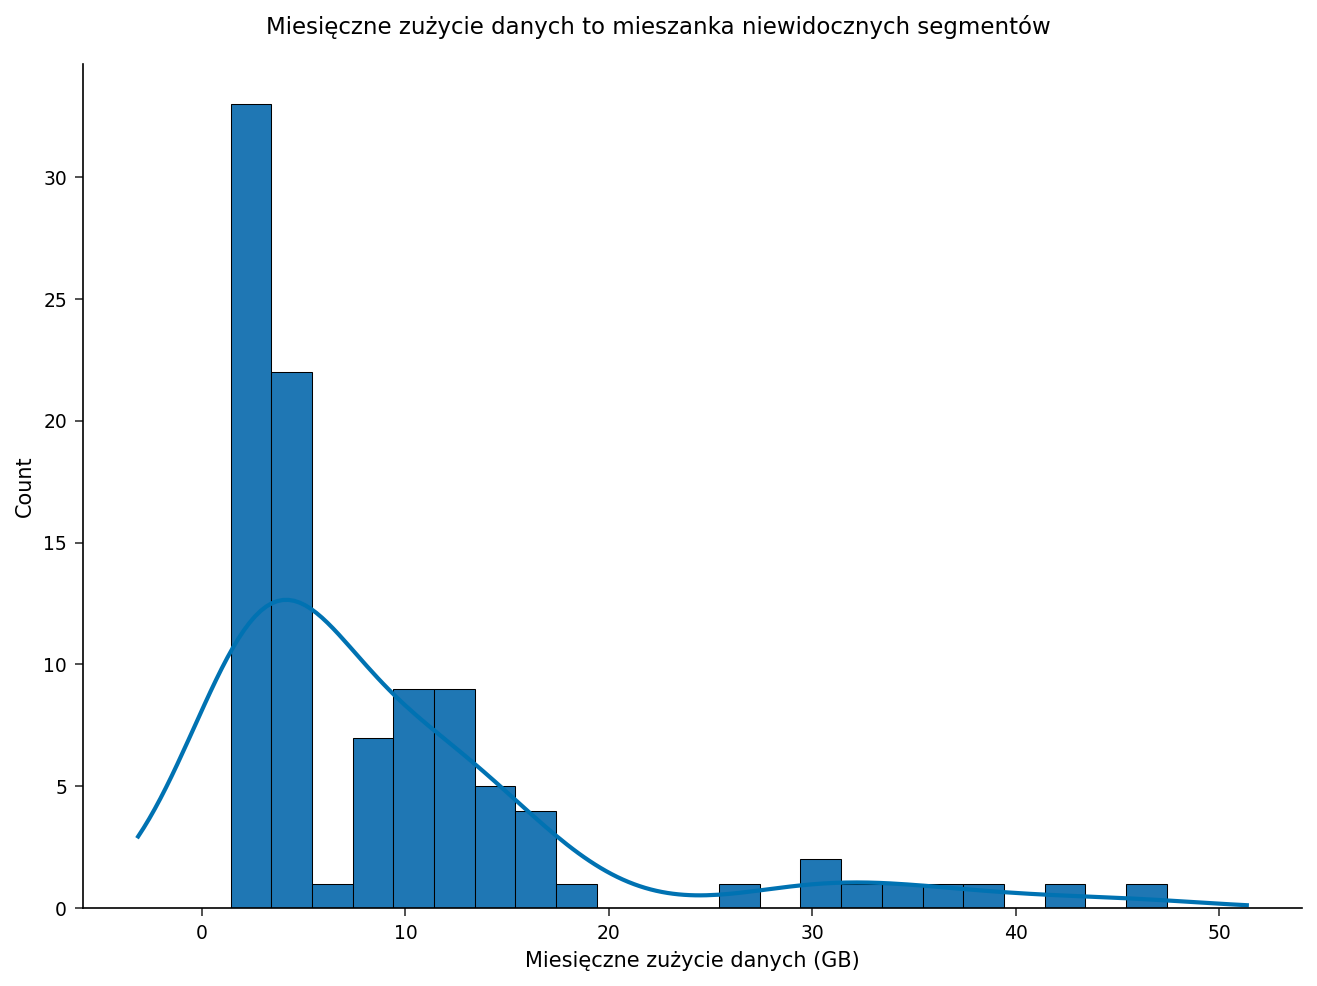

In [3]:
ODS GRAPHICS ON;
PROCEDURA SGPLOT DANE=subscribers;
   TYTUŁ 'Miesięczne zużycie danych to mieszanka niewidocznych segmentów';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ETYKIETA='Miesięczne zużycie danych (GB)';
WYKONAJ;
TYTUŁ;
ODS GRAPHICS OFF;

## Sprowadzenie użytkowania do wspólnej skali

*k*-średnich dzieli punkty według odległości euklidesowej, więc surowa skala zmiennej wpływa na wynik. Przy jednej mierze to jedynie przesuwa oś, ale standaryzacja do średniej 0 / odchylenia standardowego 1 za pomocą **PROC STANDARD** to nawyk, który utrzymuje poprawność przepływu pracy w chwili, gdy dodawana jest druga miara użytkowania (minuty rozmów, dni roamingu). Grupujemy na standaryzowanej kolumnie, a wyniki raportujemy z powrotem w oryginalnej skali GB.

In [4]:
PROCEDURA STANDARD DANE=subscribers out=subs_std mean=0 std=1;
   ZMIENNA data_gb;
WYKONAJ;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Podział abonentów na trzy segmenty użytkowania

Kierując się wiedzą dziedzinową o poziomach lekki / umiarkowany / intensywny, prosimy **PROC FASTCLUS** o `MAXCLUSTERS=3`. Procedura inicjuje trzy środki, przypisuje każdego abonenta do najbliższego, przelicza środki i iteruje, aż przypisania przestaną się zmieniać (`CONVERGE=` z limitem `MAXITER=`). `SEED=` zapewnia powtarzalność inicjalizacji. Zbiór `OUT=` niesie etykietę `CLUSTER` każdego abonenta oraz jego `DISTANCE` do przypisanego środka; `MEAN=` zapisuje centroidy segmentów.

Odczytaj diagnostykę procedury pod kątem jakości separacji: wysoki **R-kwadrat** (udział całkowitej wariancji użytkowania wyjaśniony przez segmenty) oraz duże **Pseudo F** wskazują na dobrze oddzielone, zwarte segmenty.

In [5]:
PROCEDURA FASTCLUS DANE=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   ZMIENNA data_gb;
   TYTUŁ 'Trzy segmenty użytkowania metodą k-średnich';
WYKONAJ;
TYTUŁ;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profilowanie odkrytych segmentów

Etykiety skupień stają się użyteczne dopiero wtedy, gdy opiszemy każdy segment w kategoriach biznesowych. Łączymy przypisania z powrotem z oryginalnym (niestandaryzowanym) użytkowaniem i podsumowujemy wielkość każdego segmentu oraz typowe zużycie w skali GB — liczby, na których faktycznie opiera się zespół projektowania planów lub marketingu.

In [6]:
DANE memberships;
   POŁĄCZ subscribers
         clusters(ZACHOWAJ=id CLUSTER distance);
   WEDŁUG id;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=memberships n mean MIN MAX maxdec=2;
   ETYKIETA data_gb='Zuzycie danych (GB)' distance='Odleglosc';
   KLASA CLUSTER;
   ZMIENNA data_gb distance;
WYKONAJ;

PROCEDURA DRUKUJ DANE=memberships(obs=10) noobs;
   ZMIENNA id data_gb CLUSTER distance segment_true;
WYKONAJ;

                                                  The MEANS Procedure

                                    Analysis Variable : data_gb Zuzycie danych (GB)

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                         Analysis Variable : DISTANCE Odleglosc

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09        


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Walidacja odzyskanych segmentów

Ponieważ są to dane syntetyczne, wstrzymaliśmy `segment_true` — etykietę użytą do wygenerowania każdego abonenta. Krzyżowa tabulacja odzyskanego `CLUSTER` modelu względem prawdziwego segmentu pokazuje, jak wyraźnie podział rozdzielił populację. Silna koncentracja wzdłuż jednego mapowania skupienie-segment wskazuje na dobre odzyskanie; masa poza przekątną koncentruje się tam, gdzie nakładają się granice lekki/umiarkowany lub umiarkowany/intensywny.

In [7]:
PROCEDURA CZĘSTOŚCI DANE=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
WYKONAJ;

                                                   The FREQ Procedure

Table of CLUSTER by segment_true

CLUSTER |    Ciezki |     Lekki |    Sredni |      Total
--------+-----------+-----------+-----------+-----------
1       |         0 |        54 |         3 |         57
--------+-----------+-----------+-----------+-----------
2       |         9 |         0 |         0 |          9
--------+-----------+-----------+-----------+-----------
3       |         1 |         0 |        33 |         34
--------+-----------+-----------+-----------+-----------
Total   |        10 |        54 |        36 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretacja wyników

- **Środki segmentów.** Trzy skupienia trafiają niemal dokładnie w zaplanowane poziomy użytkowania — lekcy użytkownicy blisko **3 GB**, umiarkowani blisko **13 GB**, a intensywni blisko **37 GB** — kwantyfikując zarówno *gdzie* leży każdy segment, jak i *jak duży* jest. Mały segment intensywnych użytkowników, mimo że stanowi tylko ułamek abonentów, odpowiada za nieproporcjonalnie duży udział całkowitych przenoszonych danych — klasyczny czynnik decyzji o pojemności sieci i planach premium.
- **Jakość separacji.** PROC FASTCLUS raportuje wysoki ogólny **R-kwadrat** oraz duże **Pseudo F**, potwierdzając, że trzy segmenty są zwarte i dobrze oddzielone, a nie artefaktem dowolnego cięcia. Pojedynczy poziom pozostawiłby większość tej wariancji użytkowania niewyjaśnioną.
- **Brak ręcznie dobieranych progów.** Segmentacja wyłania się z samej geometrii rozkładu użytkowania. Procedura wybrała granice; my wybraliśmy jedynie *ile* poziomów zamówić, kierując się oczywistym trójmodalnym kształtem na histogramie.
- **Wynik praktyczny.** Zbiór `OUT=` daje każdemu abonentowi etykietę segmentu *oraz* `DISTANCE` do jego środka. Abonenci daleko od jakiegokolwiek środka — lub znajdujący się między granicą lekki/umiarkowany — to dokładnie klienci warci testów A/B z ofertami upsellingowymi, podczas gdy ściśle skupieni intensywni użytkownicy to kandydaci o wysokiej pewności do planów uwzględniających pojemność lub nielimitowanych.

Podsumowując, PROC FASTCLUS zamienia jedną ciągłą miarę użytkowania w segmentację opartą na danych — bez konieczności ręcznego doboru progów GB — a krzyżowa tabulacja względem ukrytej prawdy potwierdza, że segmenty są odzyskiwane wiarygodnie.